In [2]:
# System libraries
from pathlib import Path
import os

# Standard libraries
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy.stats import pearsonr
import anndata as ad

# DL libraries
import crested

## Prepare data paths
Download the data for the notebooks from the dedicated Zenodo link of the CREsted paper. Then use it below.

In [3]:
# Data paths
data_dir = Path("crested_data/Figure_5/") # CHANGE TO OWN LOCATION OF EXTRACTED crested_data.tar.gz
adata_file = data_dir / "data/mouse_biccn_data_full.h5ad" # see data/README.md, data from crested.get_dataset("mouse_cortex_bigwig_cut_sites")
adata_filtered_file = data_dir / "data/mouse_biccn_data_specific.h5ad"
temp_preds_dir = data_dir / 'data' / 'temp_preds'
# Genome paths
resources_dir = Path("mm10_ucsc/fasta/") # CHANGE TO OWN
genome_file = resources_dir / "mm10.fa"
chromsizes_file = resources_dir / "mm10.chrom.sizes"

In [4]:
genome = crested.Genome(genome_file, chromsizes_file)
crested.register_genome(genome)

2025-08-29T11:02:10.300749+0200 INFO Genome mm10 registered.


## Load data

In [7]:
adata = ad.read_h5ad(adata_file)
crested.pp.change_regions_width(
    adata,
    2048,
    chromsizes_file=chromsizes_file,
)
adata_filtered = ad.read_h5ad(adata_filtered_file)
crested.pp.change_regions_width(
    adata_filtered,
    2048,
    chromsizes_file=chromsizes_file,
)

## Calculate predictions and save
These predictions can also be found in the CREsted_data tarball, together with the other finetuning predictions, at `crested_data/Figure_5/data/temp_preds/`. That means if you have those files, there is no need to run this section.

In [5]:
# DL libraries
import torch
from transformers import AutoModel, AutoTokenizer

# Manual code
from utils_nuctrans import NucTransTokenizerAnnDataModule, NucTransScalarModel
from utils_hyenadna import HyenaDNATokenizerAnnDataModule, build_hyenadna_model, CharacterTokenizerv2, HyenaDNAScalarModel

/lustre1/project/stg_00002/lcb/cblaauw/software/mambaforge/envs/crested_py311_pt251_test/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# Use dataloader instead so that we use batching
def general_predict(dataloader, model):
    preds = []
    with torch.no_grad():
        for tokens, labels in tqdm(dataloader):
            pred = model.model_pass(tokens).detach().cpu().numpy()
            preds.append(pred)
    preds = np.concatenate(preds, axis = 0)
    preds = preds.T
    return preds

### HyenaDNA models

In [14]:
tokenizer = CharacterTokenizerv2(characters=['A', 'C', 'G', 'T', 'N'], model_max_length = 32_000)
base_model = build_hyenadna_model('hyenadna-small-32k-seqlen')

Loaded pretrained weights ok!


In [15]:
datamodule = HyenaDNATokenizerAnnDataModule(
    adata = adata,
    genome = genome,
    batch_size=64,  # lower this if you encounter OOM errors
    max_stochastic_shift=3, # this will be disabled for predictions anyway
    always_reverse_complement=True, # this will be disabled for predictions anyway
    tokenizer = tokenizer,
    in_memory=True
)
datamodule.setup('predict')

In [ ]:
# HyenaDNA - finetuned once on consensus regions
model_name = 'hyenadna_lowlr_ft_consensus'
# model_path = 'hyenadna/lightning_logs/version_5/checkpoints/epoch=13-step=385882.ckpt' # high lr
model_path = 'hyenadna/lightning_logs/version_11/checkpoints/epoch=20-step=578823.ckpt' # lowered lr -> better 

model = HyenaDNAScalarModel.load_from_checkpoint(
    model_path, 
    base_model = base_model,
).to('cuda')

saved_preds_full_path = os.path.join(temp_preds_dir, f"{model_name}_preds_full.npz")
saved_preds_ct_path = os.path.join(temp_preds_dir, f"{model_name}_preds_ct.npz")
# If preds aren't saved, save them now:
preds = general_predict(datamodule.predict_dataloader.data, model)
if not os.path.exists(saved_preds_full_path):
    np.savez(saved_preds_full_path, preds)
    print(f"Saved full predictions to {saved_preds_full_path}")
preds_ct = preds[:, adata.var_names.isin(adata_filtered.var_names)]
assert preds_ct.shape[1] > 0, "Check if adata and adata_filtered var names match (region sizes especially)"
if not os.path.exists(saved_preds_ct_path):
    np.savez(saved_preds_ct_path, preds_ct)
    print(f"Saved ct-specific predictions to {saved_preds_ct_path}")

  1%|          | 48/8547 [00:09<18:27,  7.67it/s] 

In [9]:
# HyenaDNA - finetuned twice, on consensus regions and then on specific regions
model_name = 'hyenadna_lowlr__ft_consensus_ft_specific'
# model_path = 'hyenadna/lightning_logs/version_10/checkpoints/epoch=3-step=18332.ckpt' # high lr
model_path = 'hyenadna/lightning_logs/version_12/checkpoints/' # lowered lr -> better 

model = HyenaDNAScalarModel.load_from_checkpoint(
    model_path, 
    base_model = base_model,
).to('cuda')

saved_preds_full_path = os.path.join(temp_preds_dir, f"{model_name}_preds_full.npz")
saved_preds_ct_path = os.path.join(temp_preds_dir, f"{model_name}_preds_ct.npz")
# If preds aren't saved, save them now:
preds = general_predict(datamodule.predict_dataloader.data, model)
if not os.path.exists(saved_preds_full_path):
    np.savez(saved_preds_full_path, preds)
    print(f"Saved full predictions to {saved_preds_full_path}")
preds_ct = preds[:, adata.var_names.isin(adata_filtered.var_names)]
assert preds_ct.shape[1] > 0, "Check if adata and adata_filtered var names match (region sizes especially)"
if not os.path.exists(saved_preds_ct_path):
    np.savez(saved_preds_ct_path, preds_ct)
    print(f"Saved ct-specific predictions to {saved_preds_ct_path}")

100%|██████████| 8547/8547 [18:28<00:00,  7.71it/s]


### Nucleotide Transformer models

In [7]:
tokenizer = AutoTokenizer.from_pretrained("InstaDeepAI/nucleotide-transformer-500m-1000g")
base_model = AutoModel.from_pretrained("InstaDeepAI/nucleotide-transformer-500m-1000g")

Some weights of EsmModel were not initialized from the model checkpoint at InstaDeepAI/nucleotide-transformer-500m-1000g and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
datamodule = NucTransTokenizerAnnDataModule(
    adata = adata,
    genome = genome,
    batch_size=16,  # lower this if you encounter OOM errors
    max_stochastic_shift=3, # this will be disabled for predictions anyway
    always_reverse_complement=True, # this will be disabled for predictions anyway
    tokenizer = tokenizer,
    in_memory=True
)
datamodule.setup('predict')

In [ ]:
# Nucleotide Transformer - finetuned once on consensus regions 
model_name = 'nuctrans_ft_consensus'
model_path = 'nuctrans/lightning_logs/version_3/checkpoints/epoch=5-step=1322982.ckpt'
model = NucTransScalarModel.load_from_checkpoint(
    model_path, 
    base_model = base_model,
).to('cuda')

saved_preds_full_path = os.path.join(temp_preds_dir, f"{model_name}_preds_full.npz")
saved_preds_ct_path = os.path.join(temp_preds_dir, f"{model_name}_preds_ct.npz")
# If preds aren't saved, save them now:
preds = general_predict(datamodule.predict_dataloader.data, model)
if not os.path.exists(saved_preds_full_path):
    np.savez(saved_preds_full_path, preds)
    print(f"Saved full predictions to {saved_preds_full_path}")
preds_ct = preds[:, adata.var_names.isin(adata_filtered.var_names)]
assert preds_ct.shape[1] > 0, "Check if adata and adata_filtered var names match (region sizes especially)"
if not os.path.exists(saved_preds_ct_path):
    np.savez(saved_preds_ct_path, preds_ct)
    print(f"Saved ct-specific predictions to {saved_preds_ct_path}")

 25%|██▍       | 8437/34188 [2:52:35<8:44:57,  1.22s/it] 

In [10]:
# Nucleotide Transformer - finetuned twice, on consensus regions and then on specific regions
model_name = 'nuctrans_ft_consensus_ft_specific'
model_path = 'nuctrans/lightning_logs/version_4/checkpoints/epoch=8-step=1432971.ckpt'
model = NucTransScalarModel.load_from_checkpoint(
    model_path, 
    base_model = base_model,
).to('cuda')

saved_preds_full_path = os.path.join(temp_preds_dir, f"{model_name}_preds_full.npz")
saved_preds_ct_path = os.path.join(temp_preds_dir, f"{model_name}_preds_ct.npz")
# If preds aren't saved, save them now:
preds = general_predict(datamodule.predict_dataloader.data, model)
if not os.path.exists(saved_preds_full_path):
    np.savez(saved_preds_full_path, preds)
    print(f"Saved full predictions to {saved_preds_full_path}")
preds_ct = preds[:, adata.var_names.isin(adata_filtered.var_names)]
assert preds_ct.shape[1] > 0, "Check if adata and adata_filtered var names match (region sizes especially)"
if not os.path.exists(saved_preds_ct_path):
    np.savez(saved_preds_ct_path, preds_ct)
    print(f"Saved ct-specific predictions to {saved_preds_ct_path}")

 33%|███▎      | 11285/34188 [3:50:39<7:46:14,  1.22s/it] IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

 56%|█████▌    | 19187/34188 [6:33:00<5:06:13,  1.22s/it]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

 68%|██████▊   | 23077/34188 [7:52:29<3:46:50,  1.22s/it]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iop

Saved full predictions to crested_data/Figure_5/data/temp_preds/nuctrans_ft_consensus_ft_specific_preds_full.npz
Saved ct-specific predictions to crested_data/Figure_5/data/temp_preds/nuctrans_ft_consensus_ft_specific_preds_ct.npz


## Calculate correlations and plot

Loads predictions saved in 'Calculate predictions and save' above for the fine-tuned gLMs, and from `CREsted-paper/Figure_5/compare_models.ipynb` for the DeepBICCN2 and Borzoi predictions. Those should all be included in the Zenodo-saved CREsted data tarball at `crested_data/Figure_5/data/temp_preds/`.

In [20]:
def calc_corr(adata, preds):
    """Calculate correlation across all regions per cell type."""
    x = np.log1p(adata.X[:, adata.var['split'] == 'test'])
    y = np.log1p(preds[:, adata.var['split'] == 'test'])
    return [pearsonr(x[class_idx, :], y[class_idx])[0] for class_idx in range(adata.n_obs)]

In [9]:
model_ids = {
    "Fine-tuned DeepBICCN2": "deepbiccn2_ft",
    "Double fine-tuned Borzoi": "borzoi_ft_consensus_ft_specific",
    "Fine-tuned HyenaDNA": "hyenadna_lowlr_ft_consensus",
    "Double fine-tuned HyenaDNA": "hyenadna_lowlr_ft_consensus_ft_specific",
    "Fine-tuned Nucleotide Transformer": "nuctrans_ft_consensus",
    "Double fine-tuned Nucleotide Transformer": "nuctrans_ft_consensus_ft_specific",
}
full_corr = {}
specific_corr = {}
for model_desc, model_id in model_ids.items():
    with np.load(os.path.join(temp_preds_dir, f"{model_id}_preds_full.npz")) as f:
        full_corr[model_desc] = calc_corr(adata, f['arr_0'])
    with np.load(os.path.join(temp_preds_dir, f"{model_id}_preds_ct.npz")) as f:
        specific_corr[model_desc] = calc_corr(adata_filtered, f['arr_0'])


### Fig. S??

/tmp/ipykernel_2790447/1976751806.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs['A'].set_xticklabels(axs['A'].get_xticklabels(), ha='right', rotation_mode='anchor')
/tmp/ipykernel_2790447/1976751806.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs['B'].set_xticklabels(axs['B'].get_xticklabels(), ha='right', rotation_mode='anchor')


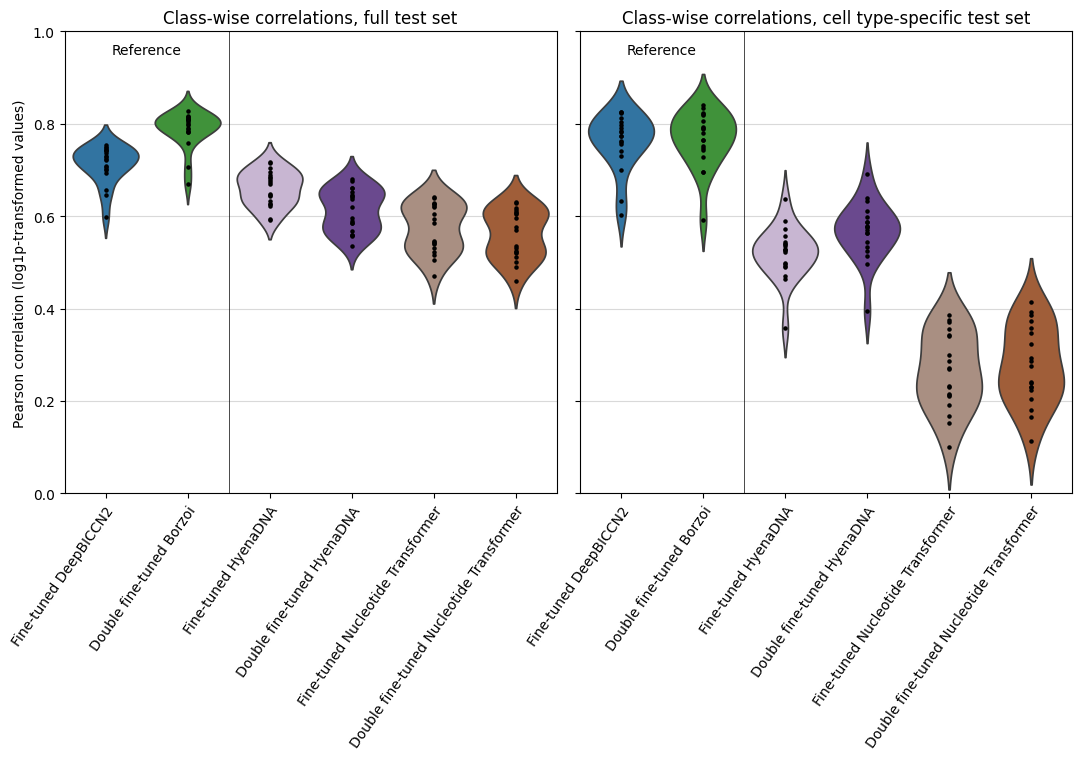

In [19]:
# Plot model performance and compare to main models
# Violin plots don't play nice with illustrator if saved as PDF. Tried to rasterize, ran into other problems.
# saving as SVG solves these issues, make sure you have matplotlib.rcParams['svg.fonttype'] = 'none' (see https://stackoverflow.com/questions/34387893/output-matplotlib-figure-to-svg-with-text-as-text-not-curves)

palette_extra = {
    "Fine-tuned DeepBICCN2": (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
    "Double fine-tuned Borzoi": (0.2, 0.6274509803921569, 0.17254901960784313),
    "Fine-tuned HyenaDNA": (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
    "Double fine-tuned HyenaDNA": (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
    "Fine-tuned Nucleotide Transformer": "#af8d7b",
    "Double fine-tuned Nucleotide Transformer": "#b15928",
}

fig, axs = plt.subplot_mosaic("AABB", sharex = True, sharey = True, figsize = (13, 6))
axs['A'].grid(visible=True, which='major', axis='y', color = '.85')
sns.violinplot(full_corr, palette = palette_extra, inner = 'point', ax = axs['A'], zorder = 2.4, orient = 'v', inner_kws={'s': 20, 'marker': '.', 'edgecolor': '0', 'color': '0.01', 'alpha': 1})
axs['A'].tick_params(axis='x', labelrotation=55)
axs['A'].set_xticklabels(axs['A'].get_xticklabels(), ha='right', rotation_mode='anchor')
axs['A'].set_ylabel("Pearson correlation (log1p-transformed values)")
axs['A'].set_ylim((0, 1))
axs['A'].set_title("Class-wise correlations, full test set")
axs['A'].axvline(1.5, c = 'black', linewidth=0.50)
axs['A'].annotate(
    "Reference",
    xy=(0.5, 0.975),
    xycoords=("data", "axes fraction"),
    verticalalignment="top",
    horizontalalignment="center"
)

axs['B'].grid(visible=True, which='major', axis='y', color = '.85')
sns.violinplot(specific_corr, palette = palette_extra, inner = 'point', ax = axs['B'], zorder = 2.4, orient='v', inner_kws={'s': 20, 'marker': '.', 'edgecolor': '0', 'color': '0.01', 'alpha': 1})
axs['B'].tick_params(axis='x', labelrotation=55)
axs['B'].set_xticklabels(axs['B'].get_xticklabels(), ha='right', rotation_mode='anchor')
axs['B'].set_ylabel("Pearson correlation (log1p-transformed values)")
axs['B'].set_ylim((0, 1))
axs['B'].set_title("Class-wise correlations, cell type-specific test set")
axs['B'].axvline(1.5, c = 'black', linewidth=0.50)

axs['B'].annotate(
    "Reference",
    xy=(0.5, 0.975),
    xycoords=("data", "axes fraction"),
    verticalalignment="top",
    horizontalalignment="center"
)
plt.subplots_adjust(wspace=0.1)

fig.savefig("corr_class_violin_glm.svg", bbox_inches = 'tight', dpi = 1000)
fig.show()
fig